# Task 2: EfficientNet-B0 for 60x80 Images

This notebook compares two completed EfficientNet-B0 experiments on the same frozen validation split: the original unweighted-loss run preserved in Git and the latest class-weighted run preserved in the current checkpoint. EfficientNet-B0 uses mobile inverted bottleneck blocks and squeeze-and-excitation attention while remaining relatively compact.

Both experiments use `weights=None`; all parameters are learned from the supplied training data, so neither experiment uses transfer learning or fine-tuning. The baseline evidence in Sections 3.1–3.2 is archival and is not rerun. Sections 3.3–3.5 restore, analyse, and select the latest compatible EfficientNet checkpoint.


## 0. EfficientNet-B0 model

EfficientNet-B0 is a convolutional neural network that scales network depth, width, and input resolution in a coordinated way. Its mobile inverted bottleneck blocks learn local-to-global visual patterns, while squeeze-and-excitation components adaptively emphasise informative channels. This makes it a compact candidate for learning garment shape, colour, texture, and layout directly from the prepared RGB images. For the small 60x80 inputs, the later stage-6 stride is changed from two to one so that the final feature map remains 5x4 rather than discarding too much spatial information.

Notebook 02 first established a Random Forest baseline using 2,007 engineered colour, edge, texture, and spatial-summary features. It achieved 66.77% validation accuracy and 0.6840 macro-F1. This showed that the handcrafted features contain useful seasonal information, but they compress the image and cannot learn task-specific spatial representations. EfficientNet-B0 was therefore chosen as the next candidate: it can learn hierarchical features end to end while remaining smaller and cheaper than many CNN alternatives. The unweighted EfficientNet experiment improved over Random Forest by 8.34 percentage points in accuracy and 6.14 points in macro-F1 on the same frozen validation split, supporting the move from engineered features to a learned image representation.

No pretrained weights are used (`weights=None`). All convolutional and classifier parameters are learned from the supplied training data, satisfying the assignment restriction and making the Random Forest and CNN comparison specific to the available dataset.


## How to Run

Run `01_task2_setup.ipynb` first. A normal run restores the completed weighted checkpoint because its configuration and data fingerprint match; it does not repeat the 40-epoch training. The unweighted baseline in Section 3.1 is deliberately retained as read-only evidence from the Git version of this notebook.


## Required Structure to Run

Run Notebook 01 first so that its prepared-data contract exists. `pyproject.toml` identifies the repository root, while `src/task2_utils.py` provides the model builder, data stream, training loop, evaluation logic, and checkpoint safeguards.

```text
Machine-Learning-Assignment-2/
├── pyproject.toml
├── src/
│   └── task2_utils.py
└── preprocessed_datasets/
    └── task2/
        ├── task2_metadata.json
        ├── task2_deep_learning_train_images.npy
        ├── task2_deep_learning_validation_images.npy
        ├── task2_random_forest_train_features.npy
        └── task2_random_forest_validation_features.npy
```

EfficientNet trains on the two deep-learning image arrays. The Random Forest arrays are listed because the current shared loader validates the complete Notebook 01 package even though this model does not use those features. This notebook creates `models/task2/checkpoints/model_efficientnet_b0.pt`; the destination directory is created automatically. A compatible checkpoint may be restored instead of retrained.

## 1. Setup


In [1]:
%matplotlib inline
from IPython.display import display


In [2]:
from pathlib import Path
import sys

REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / "pyproject.toml").exists()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not find the repository root containing pyproject.toml")
sys.path.insert(0, str(REPO_ROOT))

from src.task2_utils import (
    NeuralTrainer, build_task2_neural_model, ensure_task2_directories,
    model_checkpoint_path, neural_training_config, prepared_namespace, result_frame,
)
ensure_task2_directories()


### 1.1 Configuration

The settings below are controlled choices for this experiment rather than the result of an exhaustive hyperparameter search:

- **40 epochs:** gives a from-scratch CNN enough optimisation steps to converge. The validation curves flatten late in training, showing that this budget was sufficient.
- **Batch size 64:** balances stable gradient estimates with memory use for the 60x80 tensors and provides 473 parameter updates per epoch.
- **AdamW, learning rate `4e-4`, and weight decay `6e-4`:** AdamW provides adaptive updates for from-scratch training; the moderate starting rate supports useful progress without unstable jumps, while decoupled weight decay discourages overly large parameters.
- **Three warm-up epochs followed by cosine decay:** warm-up avoids aggressive early updates while representations are still unformed; cosine decay then makes progressively smaller refinements near convergence.
- **Label smoothing `0.08`:** reduces pressure toward extreme confidence, which is useful because seasonal labels overlap visually and may contain ambiguity.
- **Class-weight power `0.15`:** weights are proportional to `class_count ** -0.15` and normalised to mean one. This is deliberately mild: it gives rarer seasons more influence without the instability or majority-class underfitting that full inverse-frequency weighting can introduce. The completed artifact confirms 0.15, so the notebook reports that value rather than the originally intended 0.2.
- **Flip probability `0.5`, rotation `10°`, translation `0.08`, and colour jitter `0.10`:** these small transformations model plausible catalogue-image variation while preserving garment identity and season. Validation images remain unchanged.
- **Classifier dropout `0.20`:** regularises the final classifier without heavily suppressing the learned representation.
- **Patience 7 and macro-F1 checkpointing:** training retains the epoch with the best validation macro-F1 and can stop after seven non-improving epochs. Macro-F1 is the checkpoint criterion because every season contributes equally despite unequal support.
- **Random seed 42:** fixes the experiment seed to improve repeatability.


In [ ]:
QUICK_RUN = False
RANDOM_STATE = 42
RESUME = False
# Require a supported GPU only if a compatible completed checkpoint is unavailable.
ALLOW_CPU = False

# Exact configuration embedded in the completed weighted checkpoint.
HYPERPARAMETERS = {
    "epochs": 40,
    "warmup_epochs": 3,
    "batch_size": 64,
    "patience": 7,
    "learning_rate": 4e-4,
    "weight_decay": 6e-4,
    "label_smoothing": 0.08,
    "class_weight_power": 0.15,
    "flip_probability": 0.5,
    "rotation_degrees": 10.0,
    "translate_fraction": 0.08,
    "jitter_strength": 0.10,
}
CLASSIFIER_DROPOUT = 0.20

TRAINING_CONFIG = neural_training_config(
    quick_run=QUICK_RUN, random_state=RANDOM_STATE, resume=RESUME, allow_cpu=ALLOW_CPU,
)
TRAINING_CONFIG.update(HYPERPARAMETERS)
MODEL_CONFIG = {"architecture": "efficientnet_b0_small_input", **{
    key: value for key, value in TRAINING_CONFIG.items()
    if key not in {"resume", "allow_cpu", "keep_epoch_checkpoints"}
}, "classifier_dropout": CLASSIFIER_DROPOUT,
    "base_architecture": "efficientnet_b0",
    "spatial_change": "stage6_stride_1",
}


## 2. Load Prepared Data and Shared Training Pipeline


In [4]:
data = prepared_namespace()
assert data.config.get("quick_run") == QUICK_RUN, (
    "QUICK_RUN does not match Notebook 1's prepared cache. "
    "Set the same value in both notebooks and rerun Notebook 1 if needed."
)
assert data.x_train.shape[1:] == (80, 60, 3), (
    f"Expected prepared 80x60 RGB images, got {data.x_train.shape[1:]}"
)
assert data.x_val.shape[1:] == (80, 60, 3), (
    f"Expected prepared 80x60 RGB images, got {data.x_val.shape[1:]}"
)
trainer = NeuralTrainer(data, TRAINING_CONFIG)
print(f"Loaded {len(data.train_frame):,} train and {len(data.validation_frame):,} validation rows")
print(f"Training batches per epoch: {len(trainer.train_loader)}")


Apple Metal GPU detected; using the PyTorch MPS backend.
Device: mps | mixed precision: False | run fingerprint: 5f507c7bb57f
Loaded 30,260 train and 7,566 validation rows
Training batches per epoch: 473


## 3. EfficientNet-B0 experiments

Both runs use the small-input variant, which changes stage 6 stride from two to one and preserves a 5x4 feature map for the 60x80 inputs.


### 3.1 Original configuration and output — class-weight power 0.0

The original run used the same architecture and optimisation settings, with only class weighting disabled:

```python
HYPERPARAMETERS = {
    "epochs": 40,
    "warmup_epochs": 3,
    "batch_size": 64,
    "patience": 7,
    "learning_rate": 4e-4,
    "weight_decay": 6e-4,
    "label_smoothing": 0.08,
    "class_weight_power": 0.0,
    "flip_probability": 0.5,
    "rotation_degrees": 10.0,
    "translate_fraction": 0.08,
    "jitter_strength": 0.10,
}
```

Archived Git output (restored best checkpoint, epoch 34):

| Top-1 accuracy | Macro-F1 | Balanced accuracy | Weighted F1 | Top-2 accuracy |
|---:|---:|---:|---:|---:|
| 0.751123 | 0.745440 | 0.710244 | 0.748788 | 0.942109 |

| Season | Correct | Support | Recall | Precision | F1 |
|---|---:|---:|---:|---:|---:|
| Fall | 1,313 | 2,052 | 64.0% | 73.6% | 68.4% |
| Spring | 206 | 312 | 66.0% | 92.8% | 77.2% |
| Summer | 3,133 | 3,732 | 83.9% | 73.8% | 78.6% |
| Winter | 1,031 | 1,470 | 70.1% | 78.3% | 74.0% |

The original console output recorded a best macro-F1 of 0.7454 after 4,545 seconds. These values are preserved from the committed notebook rather than recomputed from a checkpoint that has since been replaced.

**Unweighted-run learning curve (`class_weight_power = 0.0`):**

![EfficientNet-B0 unweighted training and validation loss and accuracy](../../Screenshot%202026-09-11%20at%2015.22.32.png)


### 3.2 Analysis of the original run

The unweighted model attained 75.11% accuracy and 0.7454 macro-F1. Summer dominated the validation set (3,732 of 7,566 examples) and achieved the highest recall at 83.9%. Spring predictions were precise (92.8%) but recall was only 66.0%, meaning 106 of 312 Spring examples were missed. Fall had the weakest recall (64.0%) and F1 (68.4%). The 4.09-point gap between accuracy and balanced accuracy shows that aggregate accuracy hid uneven class recall, providing a reason to test mild class weighting.


### 3.3 Latest weighted run — class-weight power 0.15

The inverse-frequency power of 0.15 mildly raises the loss contribution of under-represented seasons and lowers that of frequent seasons. The cell below is the completed run and its original output. On a future execution, `train_or_restore` validates the data fingerprint and full model configuration, then restores `model_efficientnet_b0.pt` without retraining when they match.


EfficientNet-B0 Small Input: /Users/s4030327/Machine-Learning-Assignment-2/models/task2/checkpoints/model_efficientnet_b0.pt has an incompatible model configuration; training a compatible checkpoint
Training class weights: {'Fall': np.float64(0.932), 'Spring': np.float64(1.236), 'Summer': np.float64(0.852), 'Winter': np.float64(0.98)}
[EfficientNet-B0 Small Input] starting epoch 1/40 (473 train + 15 validation batches)
[EfficientNet-B0 Small Input] finished epoch 1/40 | train loss 1.2196 | val loss 1.1011 | train accuracy 0.4822 | val accuracy 0.5118 | macro-F1 0.3211 | best 0.3211 (epoch 1) | lr 2.67e-04 | 101s
[EfficientNet-B0 Small Input] starting epoch 2/40 (473 train + 15 validation batches)
[EfficientNet-B0 Small Input] finished epoch 2/40 | train loss 1.1291 | val loss 1.0099 | train accuracy 0.5328 | val accuracy 0.5871 | macro-F1 0.5488 | best 0.5488 (epoch 2) | lr 4.00e-04 | 89s
[EfficientNet-B0 Small Input] starting epoch 3/40 (473 train + 15 validation batches)
[EfficientNe

,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-2 accuracy
0,EfficientNet-B0 Small Input,0.747291,0.745198,0.718486,0.746001,0.939202


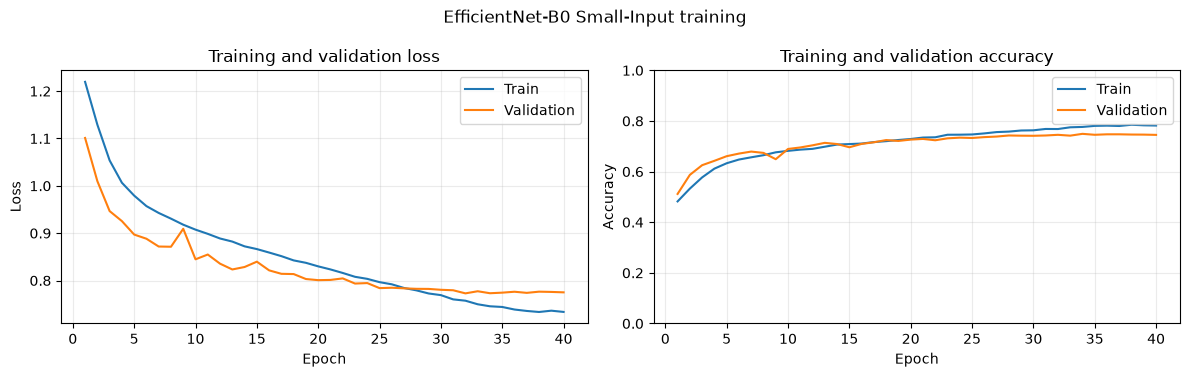

In [5]:
def build_model():
    return build_task2_neural_model(MODEL_CONFIG, data.n_classes)

efficientnet, history, logits = trainer.train_or_restore(
    "efficientnet_b0", build_model,
    "EfficientNet-B0 Small Input", MODEL_CONFIG
)
predictions = logits.argmax(axis=1)
display(result_frame(data.y_val, predictions, logits, "EfficientNet-B0 Small Input"))
trainer.plot_history(history, "EfficientNet-B0 Small-Input training")


### 3.4 Weighted-run analysis and comparison

The restored weighted checkpoint is from epoch 37. Its validation results are:

| Season | Correct | Support | Recall | Precision | F1 |
|---|---:|---:|---:|---:|---:|
| Fall | 1,354 | 2,052 | 65.98% | 72.64% | 69.15% |
| Spring | 214 | 312 | 68.59% | 90.30% | 77.96% |
| Summer | 3,035 | 3,732 | 81.32% | 74.81% | 77.93% |
| Winter | 1,051 | 1,470 | 71.50% | 74.64% | 73.04% |

| Metric | Unweighted (0.0) | Weighted (0.15) | Change |
|---|---:|---:|---:|
| Top-1 accuracy | 0.751123 | 0.747291 | -0.003832 |
| Macro-F1 | 0.745440 | 0.745198 | -0.000242 |
| Balanced accuracy | 0.710244 | 0.718486 | +0.008242 |
| Weighted F1 | 0.748788 | 0.746001 | -0.002787 |
| Top-2 accuracy | 0.942109 | 0.939202 | -0.002907 |

Weighting improved recall for Fall (+1.98 percentage points), Spring (+2.59), and Winter (+1.40), while Summer recall fell by 2.59 points. Consequently, balanced accuracy improved by 0.82 points, but macro-F1 was essentially unchanged (-0.02 points) and overall accuracy fell by 0.38 points. This is a useful redistribution of recall rather than a clear overall win: the rare Spring class benefits, but the evidence does not support claiming that mild weighting improves the primary macro-F1 metric.

The weighted learning curve does look slightly better behaved: its final train–validation accuracy gap is about 3.69 percentage points, compared with 4.12 points for the unweighted run, which suggests marginally less overfitting. However, the absolute loss levels cannot be compared directly because class weighting changes the loss being averaged. Curve smoothness alone also does not select the model; the unweighted checkpoint still has the slightly higher macro-F1 and accuracy, whereas the weighted checkpoint has meaningfully better balanced accuracy and minority-class recall.


### 3.5 Conclusion and final EfficientNet-B0 checkpoint

The final EfficientNet-B0 checkpoint for subsequent comparison is the **weighted run with `class_weight_power = 0.15`, restored from epoch 37**. It is stored at `models/task2/checkpoints/model_efficientnet_b0.pt` and is identified by data fingerprint `5f507c7bb57f`.

The unweighted run is ahead by only 0.000242 macro-F1 (0.745440 versus 0.745198), a difference too small on this single validation split to establish a meaningful performance advantage. In contrast, weighting raises balanced accuracy from 0.710244 to 0.718486 and improves recall for Fall, Spring, and Winter. Its smaller final train–validation accuracy gap also provides modest evidence of better-controlled fitting. These improvements align with the task goal of recognising every season rather than maximising performance mainly on the dominant Summer class.

Therefore, the weighted epoch-37 checkpoint is retained as the final **EfficientNet candidate** because it offers the stronger class-balance trade-off while effectively tying the best macro-F1. This is not yet the overall winner.


## 4. Confirm the completed checkpoint

The completed training checkpoint already exists in the shared checkpoint directory. Notebook 05 remains the sole owner of exporting the final selected-model package.


In [4]:
import torch

checkpoint_path = model_checkpoint_path("efficientnet_b0")
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
assert checkpoint["fingerprint"] == data.fingerprint
assert checkpoint["model_config"] == MODEL_CONFIG
assert checkpoint["model_config"]["class_weight_power"] == 0.15
print("Completed checkpoint:", checkpoint_path)
print("Class-weight power:", checkpoint["model_config"]["class_weight_power"])
print("Run fingerprint:", checkpoint["fingerprint"])


Completed checkpoint: /Users/s4030327/Machine-Learning-Assignment-2/models/task2/checkpoints/model_efficientnet_b0.pt
Class-weight power: 0.15
Run fingerprint: 5f507c7bb57f
